# Train mô hình đề xuất — Nhánh Spatial (Transformer backbone) trên FF++ C23

Notebook này **kế thừa đúng cách nạp dữ liệu, cách chia tập, cách đánh giá** từ notebook
`Train_Xception_Baseline_v1.ipynb` (cùng `CACHE_DIR`, cùng `manifest_processed.csv`, cùng
class `FFPPFrameTrainDataset` / `FFPPVideoEvalDataset`, cùng hàm `calc_metrics()`) — để đảm bảo
**so sánh công bằng, đúng protocol thống nhất nội bộ** đã cam kết trong đề cương.

**Khác so với baseline Xception:**
- Backbone đổi sang **Transformer** (mặc định Swin Transformer — có thể đổi sang CvT/ViT bằng cách
  sửa `BACKBONE_NAME`, đúng tinh thần "backbone không gian linh hoạt" trong đề cương)
- Áp dụng đúng các kỹ thuật cải tiến đã cam kết: **huấn luyện 2 giai đoạn** (đóng băng → tinh chỉnh),
  **MixUp**, **EMA**, **Label Smoothing**. TTA chỉ bật ở bước test cuối cùng (mục 8).

---

### ⚠️ Cam kết không "ăn gian" dữ liệu — đọc trước khi chạy

Notebook này **tuyệt đối không**:
- Không đụng vào `test_df` cho tới đúng 1 lần duy nhất ở Mục 7 (đánh giá cuối) — không dùng test
  để early-stop, không dùng test để chọn hyperparameter, không train trên test.
- Không tính lại mean/std chuẩn hoá ảnh từ tập train/test của FF++ — vẫn dùng ImageNet mean/std
  gốc (đúng vì backbone pretrained trên ImageNet), không "nhìn trước" thống kê của tập test.
- Không chọn ngưỡng EER dựa trên nhãn test — `calc_eer()`/`find_eer_threshold()` chỉ dùng đúng
  1 lần trên tập test để **báo cáo**, không dùng ngược lại để tinh chỉnh mô hình.
- Không loại bỏ video/frame "khó" ra khỏi test để làm đẹp số liệu.
- Mọi cải thiện AUC/EER so với baseline phải đến từ: kiến trúc tốt hơn, augmentation, chiến lược
  train 2 giai đoạn, MixUp/EMA/Label Smoothing, TTA lúc infer — **không phải từ rò rỉ dữ liệu**.

**Về mục tiêu EER < 2%:** đây là mục tiêu tham vọng, không phải con số được đảm bảo. Nếu sau khi
train nghiêm túc mà EER không xuống dưới 2%, hãy báo cáo đúng con số thật — số liệu trung thực
luôn tốt hơn số liệu bị ép cho đẹp, hội đồng có thể phát hiện nếu có bất thường (ví dụ EER=0%).

**Trước khi chạy:**
1. Settings → Accelerator → GPU (khuyến nghị P100 vì Transformer tốn VRAM hơn Xception)
2. Add Input → đúng dataset cache đã tạo → sửa `CACHE_DIR` ở Mục 1 cho khớp đường dẫn thực tế


## 1. Cấu hình

In [1]:
import os, glob, time, random, copy, json
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# ==================== SỬA ĐƯỜNG DẪN NÀY CHO KHỚP VỚI DATASET CACHE CỦA BẠN ====================
CACHE_DIR = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"   # <-- đổi lại nếu tên dataset khác
MANIFEST_CSV = os.path.join(CACHE_DIR, "manifest_processed.csv")

assert os.path.isdir(CACHE_DIR), (
    f"Không tìm thấy CACHE_DIR: {CACHE_DIR}\n"
    "=> Add Input đúng dataset cache đã tạo, rồi sửa lại biến CACHE_DIR."
)
assert os.path.exists(MANIFEST_CSV), f"Không tìm thấy manifest: {MANIFEST_CSV}"

# ==================== BACKBONE (Transformer — có thể đổi tuỳ thí nghiệm) ====================
BACKBONE_NAME = "swin_base_patch4_window7_224"
IMG_SIZE      = 224

# ==================== HYPERPARAMETERS ====================
FRAMES_PER_VIDEO_TRAIN = 6
BATCH_SIZE       = 16
GRAD_ACCUM_STEPS = 2

EPOCHS_FREEZE     = 3
EPOCHS_FINETUNE   = 17
LR_HEAD           = 1e-3
LR_BACKBONE       = 2e-5
WARMUP_EPOCHS     = 2
WEIGHT_DECAY      = 5e-2
DROP_PATH_RATE    = 0.2

MIXUP_ALPHA       = 0.2
LABEL_SMOOTH_EPS  = 0.05
EMA_DECAY         = 0.9995

PATIENCE          = 5
SEED              = 42
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "/kaggle/working/spatial_transformer"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("Device:", DEVICE)
print("Backbone:", BACKBONE_NAME)


Device: cuda
Backbone: swin_base_patch4_window7_224


## 2. Đọc manifest & thống kê nhanh

In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest = manifest[manifest["status"].isin(["ok", "skip_exists"])].reset_index(drop=True)
manifest['out_dir'] = manifest['out_dir'].str.replace('/kaggle/working/ffpp_c23_cache', CACHE_DIR)

print("Tổng video khả dụng:", len(manifest))
print(manifest.groupby(["split", "label"])["video_id"].count().unstack(fill_value=0)
      .rename(columns={0: "real", 1: "fake"}))

train_df = manifest[manifest.split == "train"].reset_index(drop=True)
val_df   = manifest[manifest.split == "val"].reset_index(drop=True)
test_df  = manifest[manifest.split == "test"].reset_index(drop=True)
print(f"\nTrain videos: {len(train_df)} | Val videos: {len(val_df)} | Test videos: {len(test_df)}")


Tổng video khả dụng: 5000
label  real  fake
split            
test    140   560
train   720  2880
val     140   560

Train videos: 3600 | Val videos: 700 | Test videos: 700


## 3. Dataset & DataLoader

In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_and_preprocess(img_path, img_size=IMG_SIZE, augment=False):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))

    if augment:
        if random.random() < 0.5:
            img = img[:, ::-1, :].copy()
        if random.random() < 0.3:
            factor = 0.85 + random.random() * 0.3
            img = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
        if random.random() < 0.2:
            mean_pix = img.mean()
            factor = 0.85 + random.random() * 0.3
            img = np.clip((img.astype(np.float32) - mean_pix) * factor + mean_pix, 0, 255).astype(np.uint8)
        if random.random() < 0.15:
            enc_quality = random.randint(70, 95)
            _, enc = cv2.imencode(".jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                                   [int(cv2.IMWRITE_JPEG_QUALITY), enc_quality])
            img = cv2.cvtColor(cv2.imdecode(enc, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    img = img.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img.transpose(2, 0, 1)).float()


class FFPPFrameTrainDataset(Dataset):
    def __init__(self, df, frames_per_video=FRAMES_PER_VIDEO_TRAIN, img_size=IMG_SIZE):
        self.samples = []
        for row in df.itertuples():
            frame_files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if len(frame_files) == 0:
                continue
            self.samples.append((frame_files, row.label))
        self.frames_per_video = frames_per_video
        self.img_size = img_size

    def __len__(self):
        return len(self.samples) * self.frames_per_video

    def __getitem__(self, idx):
        vid_idx = idx // self.frames_per_video
        frame_files, label = self.samples[vid_idx]
        img_path = random.choice(frame_files)
        img = load_and_preprocess(img_path, self.img_size, augment=True)
        return img, torch.tensor(label, dtype=torch.float32)


class FFPPVideoEvalDataset(Dataset):
    def __init__(self, df, img_size=IMG_SIZE):
        self.rows = []
        for row in df.itertuples():
            frame_files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if len(frame_files) == 0:
                continue
            self.rows.append((row.video_id, frame_files, row.label))
        self.img_size = img_size

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        video_id, frame_files, label = self.rows[idx]
        imgs = torch.stack([load_and_preprocess(f, self.img_size, augment=False) for f in frame_files])
        return imgs, torch.tensor(label, dtype=torch.float32), video_id


train_ds = FFPPFrameTrainDataset(train_df)
val_ds   = FFPPVideoEvalDataset(val_df)
test_ds  = FFPPVideoEvalDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples/epoch: {len(train_ds)} | Val videos: {len(val_ds)} | Test videos: {len(test_ds)}")


Train samples/epoch: 21600 | Val videos: 700 | Test videos: 700


## 4. Mô hình — Spatial Transformer Detector (timm)

In [4]:
!pip install -q timm


In [5]:
import timm

class SpatialTransformerDetector(nn.Module):
    def __init__(self, backbone_name=BACKBONE_NAME, pretrained=True, drop_path_rate=DROP_PATH_RATE):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained, num_classes=0, drop_path_rate=drop_path_rate
        )
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.classifier(feat).squeeze(-1)


def set_backbone_trainable(model, trainable: bool):
    for p in model.backbone.parameters():
        p.requires_grad = trainable


model = SpatialTransformerDetector(pretrained=True).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Số tham số: {n_params/1e6:.2f}M | Trainable hiện tại: {n_trainable/1e6:.2f}M")


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Số tham số: 87.01M | Trainable hiện tại: 87.01M


## 4b. Bảng chi tiết toàn bộ các lớp trong mô hình

Xuất 2 bảng để đưa vào báo cáo/slide:
1. **Bảng tóm tắt theo `torchinfo`** — input/output shape từng khối, số tham số, trạng thái
   trainable, độ sâu 3 cấp (đủ để thấy từng stage của Swin Transformer + classifier head).
2. **Bảng chi tiết từng lớp (leaf layer)** dạng `pandas.DataFrame` — liệt kê **toàn bộ** lớp
   (Conv2d, LayerNorm, Linear, Attention...) kèm tên đầy đủ, loại lớp, số tham số, có train hay
   không — lưu ra `model_layers_table.csv` để dán trực tiếp vào phụ lục báo cáo.

In [6]:
!pip install -q torchinfo


In [7]:
from torchinfo import summary as torchinfo_summary

print("=" * 100)
print(f"TÓM TẮT KIẾN TRÚC — {BACKBONE_NAME} + classifier head (torchinfo, depth=3)")
print("=" * 100)
model_summary = torchinfo_summary(
    model,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3,
    verbose=0,
)
print(model_summary)

with open(os.path.join(OUT_DIR, "model_summary_torchinfo.txt"), "w", encoding="utf-8") as f:
    f.write(str(model_summary))


TÓM TẮT KIẾN TRÚC — swin_base_patch4_window7_224 + classifier head (torchinfo, depth=3)
Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
SpatialTransformerDetector                              [1, 3, 224, 224]          [1]                       --                        True
├─SwinTransformer: 1-1                                  [1, 3, 224, 224]          [1, 1024]                 --                        True
│    └─PatchEmbed: 2-1                                  [1, 3, 224, 224]          [1, 56, 56, 128]          --                        True
│    │    └─Conv2d: 3-1                                 [1, 3, 224, 224]          [1, 128, 56, 56]          6,272                     True
│    │    └─LayerNorm: 3-2                              [1, 56, 56, 128]          [1, 56, 56, 128]          256                       True
│    └─Sequential: 2-2                                  [1, 56, 56, 128] 

In [8]:
# Bảng chi tiết TOÀN BỘ lớp (leaf modules) -- mỗi dòng là 1 lớp thật sự có trọng số/hành vi riêng
rows = []
for name, module in model.named_modules():
    if len(list(module.children())) > 0:      # bỏ qua module cha (Sequential, block bao ngoài...)
        continue
    params = list(module.parameters())
    n_params = sum(p.numel() for p in params)
    n_trainable = sum(p.numel() for p in params if p.requires_grad)
    rows.append({
        "stt": len(rows) + 1,
        "layer_name": name if name else "(root)",
        "layer_type": module.__class__.__name__,
        "branch": "backbone" if name.startswith("backbone") else
                  ("classifier" if name.startswith("classifier") else "khác"),
        "num_params": n_params,
        "trainable_params": n_trainable,
    })

layer_table = pd.DataFrame(rows)
layer_table.to_csv(os.path.join(OUT_DIR, "model_layers_table.csv"), index=False)

print(f"Tổng số lớp (leaf modules): {len(layer_table)}")
print(f"Tổng tham số: {layer_table['num_params'].sum()/1e6:.2f}M | "
      f"Trainable hiện tại: {layer_table['trainable_params'].sum()/1e6:.2f}M")

# Bảng tóm tắt gộp theo loại lớp -- dễ đọc hơn cho báo cáo (thay vì hàng trăm dòng riêng lẻ)
summary_by_type = (
    layer_table.groupby(["branch", "layer_type"])
    .agg(so_luong_lop=("layer_name", "count"), tong_tham_so=("num_params", "sum"))
    .sort_values("tong_tham_so", ascending=False)
    .reset_index()
)
summary_by_type.to_csv(os.path.join(OUT_DIR, "model_layers_summary_by_type.csv"), index=False)

print("\n=== Bảng tóm tắt theo loại lớp (gộp) ===")
summary_by_type


Tổng số lớp (leaf modules): 380
Tổng tham số: 86.94M | Trainable hiện tại: 86.94M

=== Bảng tóm tắt theo loại lớp (gộp) ===


,branch,layer_type,so_luong_lop,tong_tham_so
0,backbone,Linear,99,86615808
1,classifier,Linear,2,262657
2,backbone,LayerNorm,53,57600
3,backbone,Conv2d,1,6272
4,classifier,LayerNorm,1,2048
5,backbone,GELU,24,0
6,backbone,FastAdaptiveAvgPool,1,0
7,backbone,Dropout,97,0
8,backbone,DropPath,46,0
9,backbone,Softmax,24,0


In [9]:
# Xem toàn bộ bảng chi tiết từng lớp (không gộp) -- kéo xuống nếu cần copy vào phụ lục báo cáo
pd.set_option("display.max_rows", 200)
layer_table


,stt,layer_name,layer_type,branch,num_params,trainable_params
0,1,backbone.patch_embed.proj,Conv2d,backbone,6272,6272
1,2,backbone.patch_embed.norm,LayerNorm,backbone,256,256
2,3,backbone.layers.0.downsample,Identity,backbone,0,0
3,4,backbone.layers.0.blocks.0.norm1,LayerNorm,backbone,256,256
4,5,backbone.layers.0.blocks.0.attn.qkv,Linear,backbone,49536,49536
...,...,...,...,...,...,...
375,376,classifier.0,LayerNorm,classifier,2048,2048
376,377,classifier.1,Linear,classifier,262400,262400
377,378,classifier.2,GELU,classifier,0,0
378,379,classifier.3,Dropout,classifier,0,0


## 5. Hàm tính metric (EER/AUC/Accuracy/FAR/FRR)

Copy nguyên vẹn từ notebook baseline — bắt buộc dùng chung 1 công thức cho mọi mô hình.

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer


def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])


def calc_far_frr(y_true, y_score, threshold):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    return far, frr, cm


def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    return {
        "acc": acc, "auc": auc, "eer": eer,
        "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
        "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer, "cm_at_eer": cm_eer,
    }


## 6. MixUp / Label Smoothing / EMA

In [11]:
def mixup_batch(imgs, labels, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return imgs, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    mixed_imgs = lam * imgs + (1 - lam) * imgs[idx]
    return mixed_imgs, labels, labels[idx], lam


def smooth_labels(labels, eps=LABEL_SMOOTH_EPS):
    return labels * (1 - eps) + 0.5 * eps


class ModelEma:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema_model = copy.deepcopy(model).eval().to(DEVICE)
        for p in self.ema_model.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, ema_v in self.ema_model.state_dict().items():
            model_v = msd[k].detach()
            if ema_v.dtype.is_floating_point:
                ema_v.mul_(self.decay).add_(model_v, alpha=1 - self.decay)
            else:
                ema_v.copy_(model_v)


## 7. Vòng lặp huấn luyện — 2 giai đoạn (đóng băng → tinh chỉnh)

In [12]:
@torch.no_grad()
def evaluate(eval_model, loader):
    eval_model.eval()
    y_true, y_score, total_loss, n_videos = [], [], 0.0, 0
    loss_fn = nn.BCEWithLogitsLoss()
    for frames, label, _vid in loader:
        frames = frames.squeeze(0).to(DEVICE)
        label_dev = label.to(DEVICE)
        logits = eval_model(frames)
        # Video-level loss: dùng mean logit so với nhãn video
        mean_logit = logits.mean().unsqueeze(0)
        total_loss += loss_fn(mean_logit, label_dev).item()
        n_videos += 1
        prob_video = torch.sigmoid(mean_logit).item()
        y_score.append(prob_video)
        y_true.append(label.item())
    metrics = calc_metrics(y_true, y_score)
    metrics['val_loss'] = total_loss / max(n_videos, 1)
    return metrics


criterion = nn.BCEWithLogitsLoss()
ema = ModelEma(model, decay=EMA_DECAY)

BEST_PATH = os.path.join(OUT_DIR, "spatial_transformer_best.pth")
history = {"stage": [], "train_loss": [], "val_loss": [], "val_auc": [], "val_eer": [], "val_acc": [], "used_ema": []}
best_val_auc = -1
patience_ctr = 0
TOTAL_EPOCHS = EPOCHS_FREEZE + EPOCHS_FINETUNE
global_epoch = 0

for stage, n_epochs in [("freeze", EPOCHS_FREEZE), ("finetune", EPOCHS_FINETUNE)]:
    set_backbone_trainable(model, trainable=(stage == "finetune"))
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n=== Giai đoạn: {stage} ({n_epochs} epoch) | trainable params: {n_trainable/1e6:.2f}M ===")

    optimizer = torch.optim.AdamW([
        {"params": model.backbone.parameters(),   "lr": LR_BACKBONE if stage == "finetune" else 0.0},
        {"params": model.classifier.parameters(), "lr": LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)

    warmup_steps = WARMUP_EPOCHS * len(train_loader) if stage == "finetune" else 0
    total_steps = n_epochs * len(train_loader)

    def lr_lambda(step, warmup_steps=warmup_steps, total_steps=total_steps):
        if warmup_steps > 0 and step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * min(progress, 1.0)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
    use_mixup_ls = (stage == "finetune")

    for epoch in range(1, n_epochs + 1):
        global_epoch += 1
        model.train()
        running_loss, n_batches = 0.0, 0
        t0 = time.time()
        optimizer.zero_grad()

        for step, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if use_mixup_ls:
                imgs, y_a, y_b, lam = mixup_batch(imgs, labels)
                y_a, y_b = smooth_labels(y_a), smooth_labels(y_b)
            else:
                y_a, y_b, lam = smooth_labels(labels), smooth_labels(labels), 1.0

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = model(imgs)
                loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
                loss = loss / GRAD_ACCUM_STEPS

            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()
                if stage == "finetune":
                    ema.update(model)

            running_loss += loss.item() * GRAD_ACCUM_STEPS
            n_batches += 1

        train_loss = running_loss / max(n_batches, 1)
        val_metrics_raw = evaluate(model, val_loader)
        val_metrics_ema = evaluate(ema.ema_model, val_loader) if stage == "finetune" else val_metrics_raw
        use_ema = stage == "finetune" and val_metrics_ema["auc"] >= val_metrics_raw["auc"]
        val_metrics = val_metrics_ema if use_ema else val_metrics_raw

        history["stage"].append(stage)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics.get("val_loss", 0.0))
        history["val_auc"].append(val_metrics["auc"])
        history["val_eer"].append(val_metrics["eer"])
        history["val_acc"].append(val_metrics["acc"])
        history["used_ema"].append(use_ema)

        dt = time.time() - t0
        print(f"[{stage} {epoch:02d}/{n_epochs}] (epoch tổng {global_epoch}/{TOTAL_EPOCHS}) "
              f"loss={train_loss:.4f} | val_loss={val_metrics.get('val_loss', 0.0):.4f} | val_acc={val_metrics['acc']:.4f} val_auc={val_metrics['auc']:.4f} "
              f"val_eer={val_metrics['eer']:.4f} | {'EMA' if use_ema else 'raw'} | {dt:.1f}s")

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            patience_ctr = 0
            save_state = ema.ema_model.state_dict() if use_ema else model.state_dict()
            torch.save({"model_state": save_state, "epoch": global_epoch, "stage": stage,
                        "used_ema": use_ema, "backbone_name": BACKBONE_NAME,
                        "val_metrics": val_metrics}, BEST_PATH)
            print(f"    -> Lưu checkpoint tốt nhất (val_auc={best_val_auc:.4f}, {'EMA' if use_ema else 'raw'})")
        elif stage == "finetune":
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"Early stopping tại epoch tổng {global_epoch}")
                break



=== Giai đoạn: freeze (3 epoch) | trainable params: 0.26M ===
[freeze 01/3] (epoch tổng 1/20) loss=0.5114 | val_loss=0.4659 | val_acc=0.8000 val_auc=0.7192 val_eer=0.3500 | raw | 370.6s
    -> Lưu checkpoint tốt nhất (val_auc=0.7192, raw)
[freeze 02/3] (epoch tổng 2/20) loss=0.4969 | val_loss=0.4649 | val_acc=0.8000 val_auc=0.7594 val_eer=0.3214 | raw | 374.1s
    -> Lưu checkpoint tốt nhất (val_auc=0.7594, raw)
[freeze 03/3] (epoch tổng 3/20) loss=0.4883 | val_loss=0.4396 | val_acc=0.8014 val_auc=0.7685 val_eer=0.2893 | raw | 374.0s
    -> Lưu checkpoint tốt nhất (val_auc=0.7685, raw)

=== Giai đoạn: finetune (17 epoch) | trainable params: 87.01M ===
[finetune 01/17] (epoch tổng 4/20) loss=0.4830 | val_loss=0.4024 | val_acc=0.8029 val_auc=0.8769 val_eer=0.2107 | raw | 844.3s
    -> Lưu checkpoint tốt nhất (val_auc=0.8769, raw)
[finetune 02/17] (epoch tổng 5/20) loss=0.4229 | val_loss=0.2537 | val_acc=0.8800 val_auc=0.9693 val_eer=0.0804 | raw | 844.6s
    -> Lưu checkpoint tốt nhất (

## 8. Đánh giá cuối cùng trên tập test (intra-FF++ C23) — có TTA

Nạp checkpoint tốt nhất: epoch=16 stage=finetune used_ema=True (val_auc=0.9922)

=== KẾT QUẢ TEST (intra-FF++ C23) — Spatial Transformer (đề xuất) + TTA ===
Accuracy            : 96.57%
AUC                 : 99.26%
EER                 : 2.86%
FAR @ threshold=0.5 : 2.14%
FRR @ threshold=0.5 : 8.57%
Ngưỡng tại EER      : 0.6801
FAR @ ngưỡng EER    : 2.86%
FRR @ ngưỡng EER    : 2.86%

=== Ma trận nhầm lẫn @ threshold=0.5 ===
                 Dự đoán Real   Dự đoán Fake
Thực tế Real             128             12
Thực tế Fake              12            548


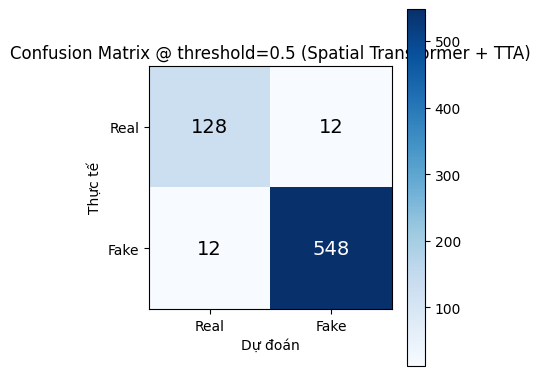


[Đối chiếu] AUC không TTA: 99.28%  |  AUC có TTA: 99.26%  (chênh lệch: -0.03 điểm %)

Đã lưu kết quả đầy đủ vào /kaggle/working/spatial_transformer/test_results_intra.csv


In [13]:
@torch.no_grad()
def evaluate_with_tta(eval_model, loader, use_tta=True):
    eval_model.eval()
    y_true, y_score = [], []
    for frames, label, _vid in loader:
        frames = frames.squeeze(0).to(DEVICE)
        logits = eval_model(frames)
        probs = torch.sigmoid(logits)
        if use_tta:
            frames_flip = torch.flip(frames, dims=[3])
            logits_flip = eval_model(frames_flip)
            probs_flip = torch.sigmoid(logits_flip)
            probs = (probs + probs_flip) / 2.0
        y_score.append(probs.mean().item())
        y_true.append(label.item())
    return calc_metrics(y_true, y_score)


ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
final_model = SpatialTransformerDetector(pretrained=False).to(DEVICE)
final_model.load_state_dict(ckpt["model_state"])
print(f"Nạp checkpoint tốt nhất: epoch={ckpt['epoch']} stage={ckpt['stage']} "
      f"used_ema={ckpt['used_ema']} (val_auc={ckpt['val_metrics']['auc']:.4f})")

test_metrics = evaluate_with_tta(final_model, test_loader, use_tta=True)
print("\n=== KẾT QUẢ TEST (intra-FF++ C23) — Spatial Transformer (đề xuất) + TTA ===")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")
print(f"Ngưỡng tại EER      : {test_metrics['eer_threshold']:.4f}")
print(f"FAR @ ngưỡng EER    : {test_metrics['far_at_eer']*100:.2f}%")
print(f"FRR @ ngưỡng EER    : {test_metrics['frr_at_eer']*100:.2f}%")

print("\n=== Ma trận nhầm lẫn @ threshold=0.5 ===")
cm = test_metrics["cm_at_0.5"]
print("                 Dự đoán Real   Dự đoán Fake")
print(f"Thực tế Real      {cm[0,0]:>10d}   {cm[0,1]:>12d}")
print(f"Thực tế Fake      {cm[1,0]:>10d}   {cm[1,1]:>12d}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title("Confusion Matrix @ threshold=0.5 (Spatial Transformer + TTA)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=100)
plt.show()

test_metrics_no_tta = evaluate_with_tta(final_model, test_loader, use_tta=False)
print(f"\n[Đối chiếu] AUC không TTA: {test_metrics_no_tta['auc']*100:.2f}%  |  "
      f"AUC có TTA: {test_metrics['auc']*100:.2f}%  (chênh lệch: "
      f"{(test_metrics['auc']-test_metrics_no_tta['auc'])*100:+.2f} điểm %)")

result_row = {
    "model": f"SpatialTransformer_{BACKBONE_NAME}", "params_M": round(n_params / 1e6, 2),
    "acc_intra": test_metrics["acc"], "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
    "far_at_eer_intra": test_metrics["far_at_eer"], "frr_at_eer_intra": test_metrics["frr_at_eer"],
    "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
    "auc_no_tta": test_metrics_no_tta["auc"], "eer_no_tta": test_metrics_no_tta["eer"],
}
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)
print(f"\nĐã lưu kết quả đầy đủ vào {OUT_DIR}/test_results_intra.csv")


## 9. Vẽ đường cong huấn luyện (kiểm tra overfitting)

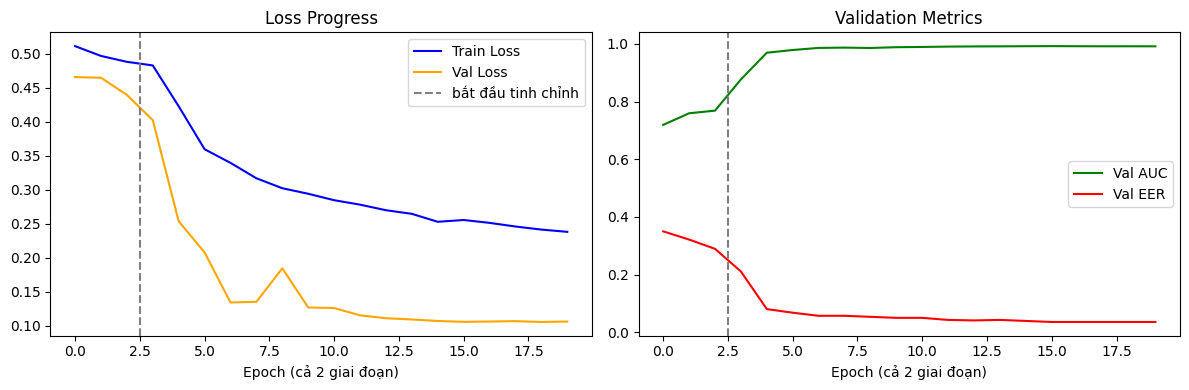

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train Loss", color="blue")
if "val_loss" in history and len(history["val_loss"]) > 0:
    axes[0].plot(history["val_loss"], label="Val Loss", color="orange")
axes[0].set_title("Loss Progress")
axes[0].set_xlabel("Epoch (cả 2 giai đoạn)")
axes[0].axvline(EPOCHS_FREEZE - 0.5, color="gray", linestyle="--", label="bắt đầu tinh chỉnh")
axes[0].legend()

axes[1].plot(history["val_auc"], label="Val AUC", color="green")
axes[1].plot(history["val_eer"], label="Val EER", color="red")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch (cả 2 giai đoạn)")
axes[1].axvline(EPOCHS_FREEZE - 0.5, color="gray", linestyle="--")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=100)
plt.show()

pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "train_history.csv"), index=False)


## 10. ⚠️ Lưu kết quả vĩnh viễn & bước tiếp theo

**Save Version → Save & Run All (Commit)** → tab **Output** → **New Dataset** để lưu lại:
- `spatial_transformer_best.pth` — dùng để **warm-start nhánh spatial** khi ghép fusion qua CAN
  (load state_dict này vào submodule spatial của `DeepfakeFusionModel`, không phải "ghép file")
- `train_history.csv`, `test_results_intra.csv`, `training_curves.png`, `confusion_matrix.png`

**Bước tiếp theo:** dùng `test_results_intra.csv` của notebook này + của Xception/SBI/UCF/Wu et al.
để gộp thành bảng so sánh chính (Chương 3). Nếu AUC/EER chưa đạt kỳ vọng, hướng cải thiện hợp lệ:
tăng `EPOCHS_FINETUNE`, thử `BACKBONE_NAME` khác, tăng `FRAMES_PER_VIDEO_TRAIN`, hoặc tinh chỉnh
`MIXUP_ALPHA`/`DROP_PATH_RATE` — **không hạ chuẩn cách đánh giá hay đụng vào tập test**.